In [3]:
"""
Non-dimensionalized pheromone-enzyme system solver.

Spherical coordinates (r, theta) centered on cell of unit radius.
Domain: r in [1, r_max], theta in [0, pi].
theta = 0 points toward the external source.

Fields:
  Q(r) = gamma/r                     [known, harmonic]
  P(r,theta) = total external species [Laplace + point source, Robin BC]
  psi(r,theta) = complex concentration [nonlinear reaction-diffusion, Neumann BC]

Recovered fields:
  phi = Q - psi   (enzyme)
  chi = P - psi   (free pheromone)

Equations (boxed on whiteboard):
  (e):   nabla^2 Q = 0                 => Q = gamma/r
  (5+6): dr Q|_1 = -gamma
  (1):   nabla^2 P + 4*pi*alpha * delta^3(r - rho0 zhat) = 0
  (2+6): dr P|_1 = beta * [P(1,th) - psi(1,th)]
  (3):   nabla^2 psi + 4*pi*zeta * [(Q-psi)(P-psi) - kappa*psi] = 0
         dr psi|_1 = 0

Parameters:
  gamma = cell emission rate
  alpha = external source strength
  beta  = absorption rate at cell wall (Robin)
  zeta  = reaction rate
  kappa = dimensionless dissociation constant
  rho0  = source distance (in cell radii)
"""

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass


@dataclass
class Params:
    gamma: float = 1.0
    alpha: float = 0.5
    beta:  float = 5.0
    zeta:  float = 5.0
    kappa: float = 0.2 # binding-unbinding of receptors on surface
    K: float = 1.0 # binding-unbinding of enzyme in medium
    rho0:  float = 5.0
    B0: float = 1.0

    def set_param (self, param, val):
      match param:
        case "gamma":
          self.gamma = val
        case "alpha":
          self.alpha = val
        case "beta":
          self.beta = val
        case "zeta":
          self.zeta = val
        case "kappa":
          self.kappa = val
        case "K":
          self.K = val
        case "rho0":
          self.rho0 = val
        case "B0":
          self.B0 = val
        case _:
          print("Warning: Not a valid parameter")

    def print_params(self):
      print(self.gamma, self.alpha, self.beta, self.zeta, self.kappa, self.K, self.rho0, self.B0)


@dataclass
class Grid:
    r_max: float = 15.0
    N_r:     int = 140
    N_theta: int = 80


class PheromoneEnzymeSolver:

    def __init__(self, params: Params, grid: Grid, show_plots=False, debug=False):
        self.p = params
        self.g = grid

        self.dr     = (grid.r_max - 1.0) / grid.N_r
        self.dtheta = np.pi / grid.N_theta

        # Cell-centred coordinates
        self.r     = 1.0 + (np.arange(grid.N_r) + 0.5) * self.dr
        self.theta = (np.arange(grid.N_theta) + 0.5) * self.dtheta
        self.R, self.THETA = np.meshgrid(self.r, self.theta, indexing='ij')

        # Precomputed trig
        self.SIN_TH = np.sin(self.THETA)
        self.COS_TH = np.cos(self.THETA)

        # Face values of sin(theta) for conservative angular differencing
        self.theta_faces = np.arange(grid.N_theta + 1) * self.dtheta  # 0 to pi
        self.sin_faces   = np.sin(self.theta_faces)  # sin(0)=0, sin(pi)=0

        # Known field
        self.Q = params.gamma / self.R

        self._build_source()

        self.show_plots = show_plots

        self.debug = debug
        if self.debug:
          print("r", self.r)
          print("theta", self.theta)
          print("R", self.R)
          print("THETA", self.THETA)
          print("SIN_THETA", self.SIN_TH)
          print("COS_THETA", self.COS_TH)
          print("theta faces", self.theta_faces)
          print("sin_faces", self.sin_faces)

    # ------------------------------------------------------------------
    def _build_source(self):
        """Regularised point source at (r=rho0, theta=0)."""
        p = self.p
        sig_r  = 2.0 * self.dr
        sig_th = 2.0 * self.dtheta
        g_r  = np.exp(-0.5 * ((self.R - p.rho0) / sig_r)**2)
        g_th = np.exp(-0.5 * (self.THETA / sig_th)**2)
        raw = g_r * g_th
        # Normalise: integral of S_P * r^2 sin(theta) dr dtheta dphi = 4*pi*alpha
        # With 2*pi from phi integral:
        integral = np.sum(raw * 2 * np.pi * self.R**2 * self.SIN_TH) \
                   * self.dr * self.dtheta
        self.S_P = raw * (4 * np.pi * p.alpha) / integral

    # ------------------------------------------------------------------
    def _angular_laplacian(self, f):
        """
        (1 / (r^2 sin(theta))) d/dtheta [sin(theta) df/dtheta]

        Conservative finite differences using face values of sin(theta).
        At theta=0 and theta=pi the faces have sin=0, so the flux
        vanishes automatically — no special pole treatment needed.
        """
        N_th = self.g.N_theta
        dth  = self.dtheta

        # Angular flux at faces: sin(theta_face) * df/dtheta
        flux = np.zeros((self.g.N_r, N_th + 1))
        flux[:, 1:-1] = self.sin_faces[1:-1][np.newaxis, :] \
                         * (f[:, 1:] - f[:, :-1]) / dth
        # flux at theta=0 and theta=pi: sin=0, so flux=0 (already zero)

        # Divergence: (1/(r^2 sin(theta))) * d(flux)/dtheta
        return (flux[:, 1:] - flux[:, :-1]) / (dth * self.R**2 * self.SIN_TH)

    # ------------------------------------------------------------------
    def _radial_laplacian(self, f, f_ghost_inner, f_ghost_outer):
        """
        (1/r^2) d/dr(r^2 df/dr) = d^2f/dr^2 + (2/r) df/dr
        """
        dr = self.dr
        r  = self.R

        f_ext = np.concatenate([f_ghost_inner[np.newaxis, :],
                                f,
                                f_ghost_outer[np.newaxis, :]], axis=0)

        d2f = (f_ext[2:, :] - 2*f_ext[1:-1, :] + f_ext[:-2, :]) / dr**2
        df  = (f_ext[2:, :] - f_ext[:-2, :]) / (2 * dr)

        return d2f + (2.0 / r) * df

    # ------------------------------------------------------------------
    def laplacian(self, f, bc_type='neumann'):
        """
        Full spherical Laplacian with boundary conditions.
        bc_type: 'neumann' or ('robin', P, psi)
        """
        # Outer BC: Dirichlet f=0
        f_ghost_outer = -f[-1, :]

        # Inner BC
        if bc_type == 'neumann':
            f_ghost_inner = f[0, :]
        elif bc_type[0] == 'robin':
            _, P, psi = bc_type
            b  = self.p.beta
            dr = self.dr
            f_ghost_inner = (P[0, :] * (1 - dr*b/2) + dr*b * psi[0, :]) \
                            / (1 + dr*b/2)
        else:
            raise ValueError(f"Unknown bc_type: {bc_type}")

        return self._radial_laplacian(f, f_ghost_inner, f_ghost_outer) \
               + self._angular_laplacian(f)

    # ------------------------------------------------------------------
    def solve(self, max_iter=200000, tol=5e-8, print_every=10000):
        p = self.p

        # CFL: radial diffusion ~ 1/dr^2, angular ~ 1/(r_min^2 * dtheta^2)
        dt = 0.3 * self.dr**2 * self.dtheta**2 \
             / (2 * (self.dr**2 + self.dtheta**2))

        # Initialise P from free-space point source
        dist = np.sqrt(self.R**2 + p.rho0**2
                       - 2 * self.R * p.rho0 * self.COS_TH)
        dist = np.maximum(dist, 0.1)
        P   = p.alpha / dist
        psi = np.zeros_like(P)
        # print(type(psi))
        # print(type(P))

        for n in range(max_iter):
            lap_P   = self.laplacian(P,   bc_type=('robin', P, psi))
            lap_psi = self.laplacian(psi, bc_type='neumann')

            dPdt    = lap_P + self.S_P
            rxn     = 4*np.pi*p.zeta * ((self.Q - psi)*(P - psi) - p.K*psi)
            dpsi_dt = lap_psi + rxn

            P_new   = P   + dt * dPdt
            psi_new = psi + dt * dpsi_dt

            psi_new = np.clip(psi_new, 0, np.minimum(self.Q, np.maximum(P, 0)))
            P_new   = np.maximum(P_new, 0)

            if n % print_every == 0:
                change = max(np.max(np.abs(P_new - P)),
                             np.max(np.abs(psi_new - psi)))
                print(f"  iter {n:7d}, max |dF| = {change:.3e}")
                if change < tol:
                    print(f"  converged at {n}")
                    break

            P, psi = P_new, psi_new

        self.P   = P
        self.psi = psi
        self.phi = self.Q - psi
        self.chi = P - psi
        if self.debug:
          print("P", P)
          print("Q", self.Q)
          print("psi", psi)
          print("chi", self.chi)
          print("phi", self.phi)
        return P, psi

    # ------------------------------------------------------------------
    def bound_snr(self):
        """
        Signal-to-noise ratio for directional sensing at the cell surface.

            SNR = int dOmega chi(1, theta) cos(theta)
                  / sqrt( int dOmega chi(1, theta) )

        where dOmega = sin(theta) dtheta dphi, and the phi integral gives 2*pi.

        The numerator measures the dipole moment of chi on the cell wall
        (how much signal distinguishes front from back).
        The denominator is sqrt of total signal (Poisson shot noise scaling).
        """
        p = self.p
        chi_surface = self.chi[0, :]     # chi at r = r_min (closest to cell wall)
        sin_th      = np.sin(self.theta)
        cos_th      = np.cos(self.theta)
        dth         = self.dtheta
        if self.debug:
          print("Chi at surface: ", chi_surface)
          print("Sin theta: ", sin_th)
          print("Cos theta: ", cos_th)
          print("Dth", dth)

        bound_complex = p.B0 * chi_surface / (chi_surface + p.kappa)

        # int dOmega f(theta) = 2*pi * int_0^pi f(theta) sin(theta) dtheta
        numerator   = 2 * np.pi * np.sum(bound_complex * cos_th * sin_th) * dth
        denominator = np.sqrt(2 * np.pi * np.sum(bound_complex * sin_th) * dth)

        return numerator / denominator

    # ------------------------------------------------------------------
    def snr(self):
        """
        Signal-to-noise ratio for directional sensing at the cell surface.

            SNR = int dOmega chi(1, theta) cos(theta)
                  / sqrt( int dOmega chi(1, theta) )

        where dOmega = sin(theta) dtheta dphi, and the phi integral gives 2*pi.

        The numerator measures the dipole moment of chi on the cell wall
        (how much signal distinguishes front from back).
        The denominator is sqrt of total signal (Poisson shot noise scaling).
        """
        chi_surface = self.chi[0, :]     # chi at r = r_min (closest to cell wall)
        sin_th      = np.sin(self.theta)
        cos_th      = np.cos(self.theta)
        dth         = self.dtheta
        if self.debug:
          print("Chi at surface: ", chi_surface)
          print("Sin theta: ", sin_th)
          print("Cos theta: ", cos_th)
          print("Dth", dth)

        # int dOmega f(theta) = 2*pi * int_0^pi f(theta) sin(theta) dtheta
        numerator   = 2 * np.pi * np.sum(chi_surface * cos_th * sin_th) * dth
        denominator = np.sqrt(2 * np.pi * np.sum(chi_surface * sin_th) * dth)

        return numerator / denominator

    # ==================================================================
    # Plotting
    # ==================================================================
    def _pad_to_poles(self, field):
        """Pad field with extra columns at theta=0 and theta=pi."""
        return np.concatenate([field[:, :1], field, field[:, -1:]], axis=1)

    def _padded_cylindrical(self):
        """Padded (r, theta) grid mapped to (z, rho_cyl)."""
        theta_pad = np.concatenate([[0.0], self.theta, [np.pi]])
        r = self.r
        R_pad, TH_pad = np.meshgrid(r, theta_pad, indexing='ij')
        Z_pad   = R_pad * np.cos(TH_pad)
        RHO_pad = R_pad * np.sin(TH_pad)
        return Z_pad, RHO_pad

    def plot_2d(self, savepath=None):
        Z, RHO = self._padded_cylindrical()

        fields = [
            (self._pad_to_poles(self.phi), 'φ (enzyme)'),
            (self._pad_to_poles(self.chi), 'χ (free pheromone)'),
            (self._pad_to_poles(self.psi), 'ψ (complex)'),
            (self._pad_to_poles(self.P),   'P = χ + ψ'),
        ]

        th = np.linspace(0, 2*np.pi, 200)
        cell_z, cell_rho = np.cos(th), np.sin(th)

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        for ax, (field, title) in zip(axes.flat, fields):
            ax.pcolormesh(Z, RHO, field, shading='gouraud', cmap='YlOrBr')
            im = ax.pcolormesh(Z, -RHO, field, shading='gouraud', cmap='YlOrBr')
            ax.plot(cell_z, cell_rho, 'k-', lw=1.5)
            ax.plot(self.p.rho0, 0, 'k+', ms=10, mew=2)
            ax.set_xlim(-5, self.p.rho0 + 3)
            ax.set_ylim(-4, 6)
            ax.set_xlabel('z')
            ax.set_ylabel('ρ')
            ax.set_title(title)
            ax.set_aspect('equal')
            plt.colorbar(im, ax=ax, shrink=0.8)

        plt.tight_layout()
        plt.show()
        if savepath:
            plt.savefig(savepath, dpi=150, bbox_inches='tight')
            plt.close()

    def plot_axis(self, axes, color="blue", savepath=None):
        # j_axis = [0, -1]  # theta closest to 0 AND pi (toward AND away from source)
        axes = ax
        plt.gcf().set_size_inches(10, 6)
        min_r_index = np.where(self.r >= self.p.rho0)[0][0]
        max_r_index = np.where(self.r >= self.p.rho0 + 2)[0][0]
        print(self.r[min_r_index])
        print(self.r[max_r_index])
        # ax.plot(self.r[:max_r_index], self.phi[:max_r_index, 0], 'r-',  lw=2, label='φ (enzyme)')
        # ax.plot(-self.r[:min_r_index], self.phi[:min_r_index, -1], 'r-',  lw=2)
        ax.plot(self.r[:max_r_index], self.chi[:max_r_index, 0], color=color,  lw=2, label='χ (free pheromone)')
        ax.plot(-self.r[:min_r_index], self.chi[:min_r_index, -1], color=color,  lw=2)
        # ax.plot(self.r[:max_r_index], self.psi[:max_r_index, 0], 'g-',  lw=2, label='ψ (complex)')
        # ax.plot(-self.r[:min_r_index], self.psi[:min_r_index, -1], 'b-',  lw=2)
        # ax.plot(self.r[:max_r_index], self.Q[:max_r_index, 0],   'r--', lw=1, alpha=0.4, label='Q = φ+ψ')
        # ax.plot(-self.r[:min_r_index], self.Q[:min_r_index, -1], 'r--',  lw=2)
        # ax.plot(self.r[:max_r_index], self.P[:max_r_index, 0],   'b--', lw=1, alpha=0.4, label='P = χ+ψ')
        # ax.plot(-self.r[:min_r_index], self.P[:min_r_index, -1], 'b--',  lw=2,)

        ax.axvline(x=1, color='gray', ls=':', alpha=0.5, label='Cell wall')
        ax.axvline(x=self.p.rho0, color='gray', ls='--', alpha=0.5,
                   label=f'Source (ρ₀={self.p.rho0})')
        ax.set_xlabel('r')
        ax.set_ylabel('Concentration')
        ax.set_title('On-axis profiles (θ=0 and θ=pi)')
        ax.legend()
        ax.set_ylim(bottom=0)
        # plt.tight_layout()
        # plt.show()
        if savepath:
            plt.savefig(savepath, dpi=150)
            plt.close()

    def plot_surface(self, savepath=None):
        theta_deg = np.degrees(self.theta)
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.plot(theta_deg, self.phi[0, :], 'r-', lw=2, label='φ (enzyme)')
        ax.plot(theta_deg, self.chi[0, :], 'b-', lw=2, label='χ (free pheromone)')
        ax.plot(theta_deg, self.psi[0, :], 'g-', lw=2, label='ψ (complex)')
        ax.set_xlabel('θ (degrees from source)')
        ax.set_ylabel('Concentration at cell surface')
        ax.set_title('Angular profile on cell wall')
        ax.legend()
        ax.set_ylim(bottom=0)
        plt.tight_layout()
        plt.show()
        if savepath:
            plt.savefig(savepath, dpi=150)
            plt.close()

    def plot_metric_heatmap (self, name="SNR", fnc=snr, param1="beta", param2="zeta", param1_max=5, param2_max=5, num_cells_per_side=25, ax=None, show_max=False, **kwargs):
      param1_vals, param2_vals = np.meshgrid(np.logspace(-2, np.log10(param1_max), num=num_cells_per_side), np.arange(0, param2_max, param2_max / num_cells_per_side))
      print(param1_vals)
      print(param2_vals)
      vals = []

      max_val = 0
      max_param1 = 0
      max_param2 = 0

      for param2_val in param2_vals[:, 0]:
        row = np.array([])
        for param1_val in param1_vals[0]:
          self.p.set_param(param1, param1_val)
          self.p.set_param(param2, param2_val)

          self._build_source()
          self.p.print_params()
          print(f"Current iteration: {param1} = {param1_val}, {param2} = {param2_val}")
          self.solve(max_iter=50000, tol=1e-7)
          val = fnc(self)
          print("SNR: ", val)
          if val > max_val:
            max_param1 = param1_val
            max_param2 = param2_val
            max_val = val
          row = np.append(row, val)
        vals.append(row)

      img = ax.imshow(np.asarray(vals), extent=[0, param1_max, 0, param2_max], cmap="YlOrBr", origin='lower')
      print(f"Max {name} = ({max_val}), reached at {param1} = {max_param1}, {param2} = {max_param2}")
      if show_max:
        ax.plot(max_param1, max_param2, 'x')
      ax.set_xlabel(f"{greek(param1)}", fontsize="x-large")
      # label = "$\\sqrt{{\\varepsilon}}$" if sqrt_eps else "$\\varepsilon$"
      ax.set_ylabel(f"{greek(param2)}", fontsize="x-large")
      ax.set_xticks([0, param1_max])
      ax.set_yticks([0, param2_max])
      ax.tick_params(labelsize="x-large")
      ax.set_title(name, pad=10)
      if param1_max > param2_max:
        ax.set_aspect(max(param1_max, param2_max) / min(param1_max, param2_max))
      else:
        ax.set_aspect(min(param1_max, param2_max) / max(param1_max, param2_max))

      return img

    def max_metric_val (self, fnc=snr, param1="beta", param2="zeta", param1_max=5, param2_max=5, num_cells_per_side=25, **kwargs):
      param1_vals, param2_vals = np.meshgrid(np.logspace(-3, np.log10(param1_max), num=num_cells_per_side), np.logspace(-3, np.log10(param2_max), num=num_cells_per_side))
      print(param1_vals)
      print(param2_vals)
      vals = []

      max_val = 0
      max_param1 = 0
      max_param2 = 0

      for param2_val in param2_vals[:, 0]:
        row = np.array([])
        for param1_val in param1_vals[0]:
          self.p.set_param(param1, param1_val)
          self.p.set_param(param2, param2_val)

          self._build_source()
          self.p.print_params()
          print(f"Current iteration: {param1} = {param1_val}, {param2} = {param2_val}")
          self.solve(max_iter=50000, tol=1e-7)
          val = fnc(self)
          print("SNR: ", val)
          if val > max_val:
            max_param1 = param1_val
            max_param2 = param2_val
            max_val = val
          row = np.append(row, val)
        vals.append(row)

      print(f"Max val = ({max_val}), reached at {param1} = {max_param1}, {param2} = {max_param2}")
      return max_param1, max_param2, max_val

    def max_val_for_multiple_kappas(self, kappa_min, kappa_max, param1="beta", param2="zeta", metric_fnc=bound_snr):
      kappa_vals = np.logspace(kappa_min, kappa_max, 10)

      data = []
      max_param1_vals = []
      max_param2_vals = []
      for val in kappa_vals:
        self.p.set_param("kappa", val)
        max_param1, max_param2, max_val= self.max_metric_val(metric_fnc, param1, param2, num_cells_per_side=7)
        max_param1_vals.append(max_param1)
        max_param2_vals.append(max_param2)
        data.append(max_val)

      # red_hue = 0
      # yellow_hue = 50 / 360
      # hsv = np.vstack((np.linspace(red_hue, yellow_hue, len(kappa_vals)), np.ones(len(kappa_vals)), np.ones(len(kappa_vals)))).transpose()
      # rgb_vals = matplotlib.colors.hsv_to_rgb(hsv)
      # plt.scatter(max_beta_vals, max_eps_vals, c=rgb_vals)
      plt.rcParams.update({'font.size': 22})
      sc = plt.scatter(max_param1_vals, max_param2_vals, c=kappa_vals, cmap="YlOrBr", norm="log")
      plt.xlabel(param1)
      plt.ylabel(param2)
      plt.gcf().colorbar(sc)

[[1.00000000e-03 4.13518554e-03 1.70997595e-02 7.07106781e-02
  2.92401774e-01 1.20913559e+00 5.00000000e+00]
 [1.00000000e-03 4.13518554e-03 1.70997595e-02 7.07106781e-02
  2.92401774e-01 1.20913559e+00 5.00000000e+00]
 [1.00000000e-03 4.13518554e-03 1.70997595e-02 7.07106781e-02
  2.92401774e-01 1.20913559e+00 5.00000000e+00]
 [1.00000000e-03 4.13518554e-03 1.70997595e-02 7.07106781e-02
  2.92401774e-01 1.20913559e+00 5.00000000e+00]
 [1.00000000e-03 4.13518554e-03 1.70997595e-02 7.07106781e-02
  2.92401774e-01 1.20913559e+00 5.00000000e+00]
 [1.00000000e-03 4.13518554e-03 1.70997595e-02 7.07106781e-02
  2.92401774e-01 1.20913559e+00 5.00000000e+00]
 [1.00000000e-03 4.13518554e-03 1.70997595e-02 7.07106781e-02
  2.92401774e-01 1.20913559e+00 5.00000000e+00]]
[[1.00000000e-03 1.00000000e-03 1.00000000e-03 1.00000000e-03
  1.00000000e-03 1.00000000e-03 1.00000000e-03]
 [4.13518554e-03 4.13518554e-03 4.13518554e-03 4.13518554e-03
  4.13518554e-03 4.13518554e-03 4.13518554e-03]
 [1.70997

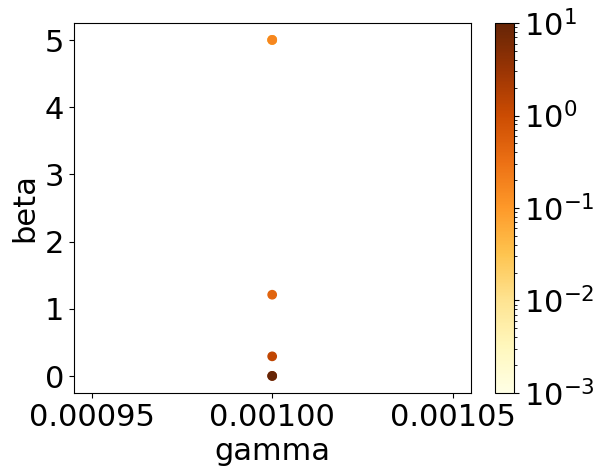

In [4]:
params = Params(
    gamma = 1.0,
    alpha = 1.0,
    beta  = 1.0,
    zeta  = 0.02,
    kappa = 1.0,
    K = 1.0,
    rho0  = 4.0,
)
grid = Grid(r_max=15.0, N_r=140, N_theta=80)

solver = PheromoneEnzymeSolver(params, grid)
solver.max_val_for_multiple_kappas(-3, 1, "gamma", "beta")


In [ ]:
A = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
A[:2, [0, -1]]


array([[1, 3],
       [4, 6]])

In [ ]:
param1_max=10
num_cells_per_side=10
np.logspace(-2, np.log10(1), num=num_cells_per_side)

array([0.01      , 0.01668101, 0.02782559, 0.04641589, 0.07742637,
       0.12915497, 0.21544347, 0.35938137, 0.59948425, 1.        ])

In [ ]:
GREEK_LETTERS = {
    "alpha":   ("α", "Α"),
    "beta":    ("β", "Β"),
    "gamma":   ("γ", "Γ"),
    "delta":   ("δ", "Δ"),
    "epsilon": ("ε", "Ε"),
    "zeta":    ("ζ", "Ζ"),
    "eta":     ("η", "Η"),
    "theta":   ("θ", "Θ"),
    "iota":    ("ι", "Ι"),
    "kappa":   ("κ", "Κ"),
    "lambda":  ("λ", "Λ"),
    "mu":      ("μ", "Μ"),
    "nu":      ("ν", "Ν"),
    "xi":      ("ξ", "Ξ"),
    "omicron": ("ο", "Ο"),
    "pi":      ("π", "Π"),
    "rho":     ("ρ", "Ρ"),
    "sigma":   ("σ", "Σ"),
    "tau":     ("τ", "Τ"),
    "upsilon": ("υ", "Υ"),
    "phi":     ("φ", "Φ"),
    "chi":     ("χ", "Χ"),
    "psi":     ("ψ", "Ψ"),
    "omega":   ("ω", "Ω"),
}


def greek(s: str) -> str:
    """Convert a romanized Greek letter name to its Unicode symbol.

    Capitalization rules:
        - ALL CAPS  (e.g. "ALPHA") → uppercase Greek letter (Α)
        - Title case (e.g. "Alpha") → uppercase Greek letter (Α)
        - Anything else (e.g. "alpha") → lowercase Greek letter (α)

    Returns None if the string is not a recognized Greek letter name.
    """
    key = s.strip().lower()
    if key not in GREEK_LETTERS:
        return s

    lower, upper = GREEK_LETTERS[key]
    if s.isupper() or (s[0].isupper() and s[1:].islower()):
        return upper
    return lower

[[0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]]
[[0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [2. 2. 2. 2. 2.]
 [3. 3. 3. 3. 3.]
 [4. 4. 4. 4. 4.]]
1.0 1.0 0.0 0.01 1.0 0.001 4.0 1.0
Current iteration: zeta = 0.01, beta = 0.0
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.425e-07
  iter   40000, max |dF| = 7.405e-07
SNR:  0.002294873050740356
1.0 1.0 0.0 0.026591479484724942 1.0 0.001 4.0 1.0
Current iteration: zeta = 0.026591479484724942, beta = 0.0
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.425e-07
  iter   40000, max |dF| = 7.405e-07
SNR:  0.00256881076205573
1.0 1.0

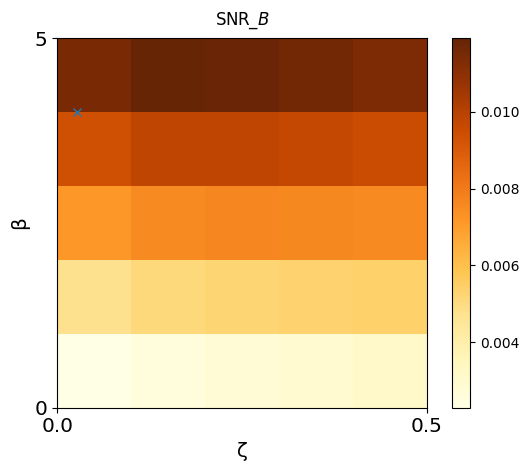

[[0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]]
[[0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [2. 2. 2. 2. 2.]
 [3. 3. 3. 3. 3.]
 [4. 4. 4. 4. 4.]]
1.0 1.0 0.0 0.01 1.0 0.01 4.0 1.0
Current iteration: zeta = 0.01, beta = 0.0
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.425e-07
  iter   40000, max |dF| = 7.405e-07
SNR:  0.02146884988316133
1.0 1.0 0.0 0.026591479484724942 1.0 0.01 4.0 1.0
Current iteration: zeta = 0.026591479484724942, beta = 0.0
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.425e-07
  iter   40000, max |dF| = 7.405e-07
SNR:  0.023869511572921255
1.0 1.0 0

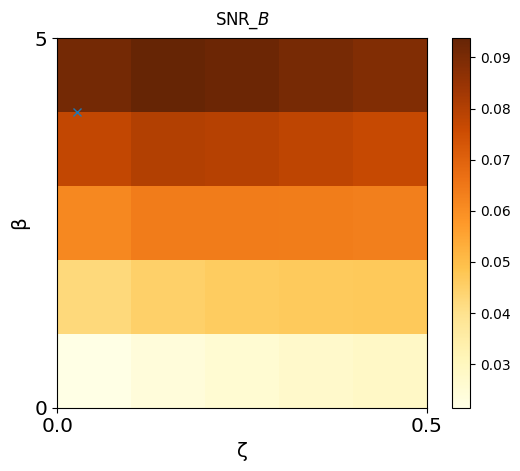

[[0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]]
[[0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [2. 2. 2. 2. 2.]
 [3. 3. 3. 3. 3.]
 [4. 4. 4. 4. 4.]]
1.0 1.0 0.0 0.01 1.0 0.1 4.0 1.0
Current iteration: zeta = 0.01, beta = 0.0
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.425e-07
  iter   40000, max |dF| = 7.405e-07
SNR:  0.12571523160152667
1.0 1.0 0.0 0.026591479484724942 1.0 0.1 4.0 1.0
Current iteration: zeta = 0.026591479484724942, beta = 0.0
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.425e-07
  iter   40000, max |dF| = 7.405e-07
SNR:  0.1338474973582721
1.0 1.0 0.0 0

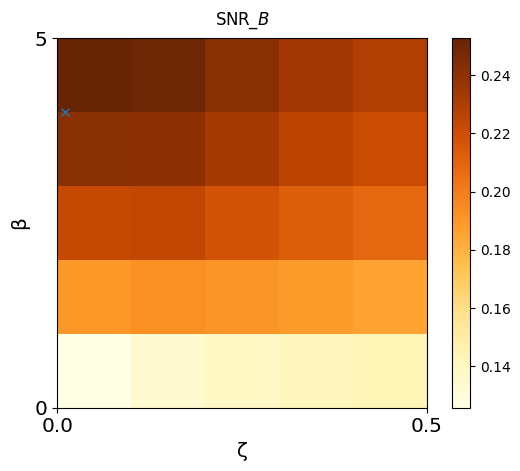

[[0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]]
[[0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [2. 2. 2. 2. 2.]
 [3. 3. 3. 3. 3.]
 [4. 4. 4. 4. 4.]]
1.0 1.0 0.0 0.01 1.0 1.0 4.0 1.0
Current iteration: zeta = 0.01, beta = 0.0
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.425e-07
  iter   40000, max |dF| = 7.405e-07
SNR:  0.16143471013414157
1.0 1.0 0.0 0.026591479484724942 1.0 1.0 4.0 1.0
Current iteration: zeta = 0.026591479484724942, beta = 0.0
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.425e-07
  iter   40000, max |dF| = 7.405e-07
SNR:  0.15990674384488077
1.0 1.0 0.0 

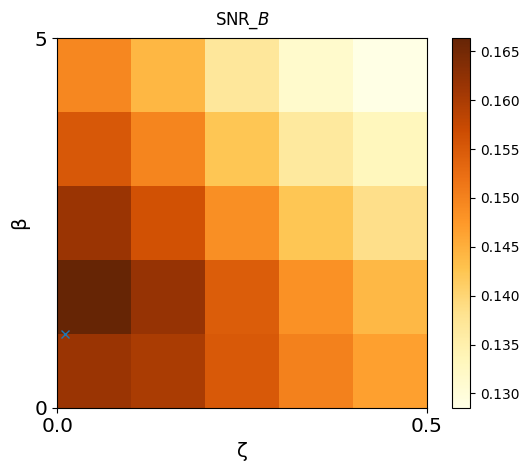

[[0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]]
[[0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [2. 2. 2. 2. 2.]
 [3. 3. 3. 3. 3.]
 [4. 4. 4. 4. 4.]]
1.0 1.0 0.0 0.01 1.0 10.0 4.0 1.0
Current iteration: zeta = 0.01, beta = 0.0
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.425e-07
  iter   40000, max |dF| = 7.405e-07
SNR:  0.06614336929586594
1.0 1.0 0.0 0.026591479484724942 1.0 10.0 4.0 1.0
Current iteration: zeta = 0.026591479484724942, beta = 0.0
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.425e-07
  iter   40000, max |dF| = 7.405e-07
SNR:  0.06411704471333962
1.0 1.0 0.

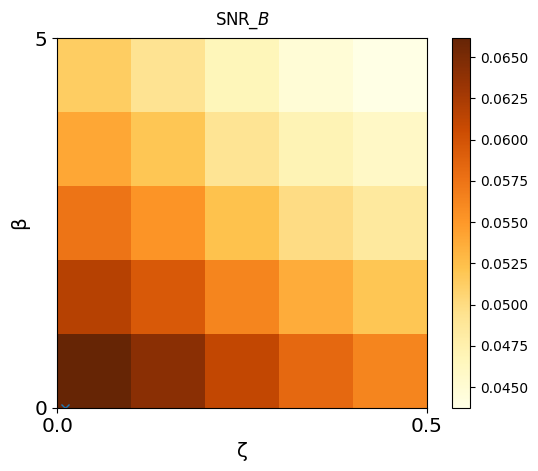

In [ ]:
K_vals = np.logspace(-3, 1, 5)

for val in K_vals:
  params = Params(
      gamma = 1.0,
      alpha = 1.0,
      beta  = 1.0,
      zeta  = 1.0,
      kappa = 1.0,
      K = val,
      rho0  = 4.0,
  )
  grid = Grid(r_max=15.0, N_r=140, N_theta=80)

  solver = PheromoneEnzymeSolver(params, grid)
  # print("Solving...")
  # solver.solve(max_iter=50000, tol=5e-8, print_every=10000)
  # print(f"\n  SNR = {solver.snr():.4f}")
  ax = plt.gca()
  img = solver.plot_metric_heatmap(name="SNR_$B$", fnc=PheromoneEnzymeSolver.bound_snr, param1="zeta", param2="beta", param1_max=0.5, num_cells_per_side=5, show_max=True, ax=ax)
  plt.gcf().colorbar(img, ax=ax)
  plt.show()

# print("\nPlotting...")
# solver.plot_2d(savepath='nondim_profiles_2d.png')
# solver.plot_axis(savepath='nondim_profiles_axis.png')
# solver.plot_surface(savepath='nondim_profiles_surface.png')
# print("Done.")

[[0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]]
[[0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [2. 2. 2. 2. 2.]
 [3. 3. 3. 3. 3.]
 [4. 4. 4. 4. 4.]]
1.0 1.0 0.0 0.01 0.001 1.0 4.0 1.0
Current iteration: zeta = 0.01, beta = 0.0
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.425e-07
  iter   40000, max |dF| = 7.405e-07
SNR:  0.1676234198583758
1.0 1.0 0.0 0.026591479484724942 0.001 1.0 4.0 1.0
Current iteration: zeta = 0.026591479484724942, beta = 0.0
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 4.222e-06
  iter   20000, max |dF| = 1.905e-06
  iter   30000, max |dF| = 1.127e-06
  iter   40000, max |dF| = 7.409e-07
SNR:  0.18366653279429057
1.0 1.0 0

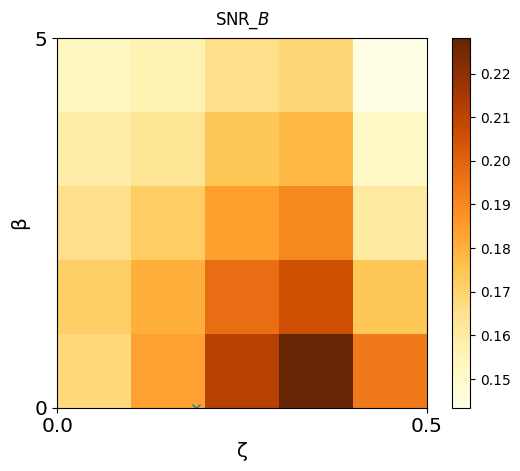

[[0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]]
[[0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [2. 2. 2. 2. 2.]
 [3. 3. 3. 3. 3.]
 [4. 4. 4. 4. 4.]]
1.0 1.0 0.0 0.01 0.01 1.0 4.0 1.0
Current iteration: zeta = 0.01, beta = 0.0
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.425e-07
  iter   40000, max |dF| = 7.405e-07
SNR:  0.16753750780538187
1.0 1.0 0.0 0.026591479484724942 0.01 1.0 4.0 1.0
Current iteration: zeta = 0.026591479484724942, beta = 0.0
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 4.197e-06
  iter   20000, max |dF| = 1.882e-06
  iter   30000, max |dF| = 1.106e-06
  iter   40000, max |dF| = 7.405e-07
SNR:  0.18306657668261736
1.0 1.0 0.

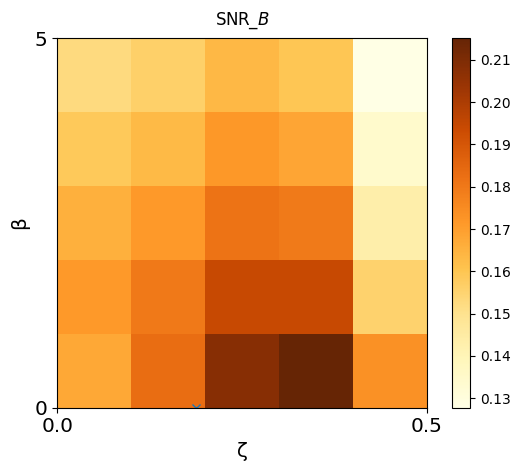

[[0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]]
[[0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [2. 2. 2. 2. 2.]
 [3. 3. 3. 3. 3.]
 [4. 4. 4. 4. 4.]]
1.0 1.0 0.0 0.01 0.1 1.0 4.0 1.0
Current iteration: zeta = 0.01, beta = 0.0
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.425e-07
  iter   40000, max |dF| = 7.405e-07
SNR:  0.16671970156792035
1.0 1.0 0.0 0.026591479484724942 0.1 1.0 4.0 1.0
Current iteration: zeta = 0.026591479484724942, beta = 0.0
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 3.948e-06
  iter   20000, max |dF| = 1.661e-06
  iter   30000, max |dF| = 9.425e-07
  iter   40000, max |dF| = 7.405e-07
SNR:  0.17791214398433153
1.0 1.0 0.0 

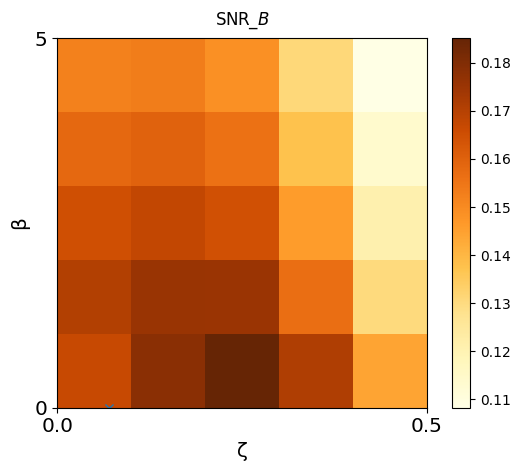

[[0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]]
[[0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [2. 2. 2. 2. 2.]
 [3. 3. 3. 3. 3.]
 [4. 4. 4. 4. 4.]]
1.0 1.0 0.0 0.01 1.0 1.0 4.0 1.0
Current iteration: zeta = 0.01, beta = 0.0
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.425e-07
  iter   40000, max |dF| = 7.405e-07
SNR:  0.16143471013414157
1.0 1.0 0.0 0.026591479484724942 1.0 1.0 4.0 1.0
Current iteration: zeta = 0.026591479484724942, beta = 0.0
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.425e-07
  iter   40000, max |dF| = 7.405e-07
SNR:  0.15990674384488077
1.0 1.0 0.0 

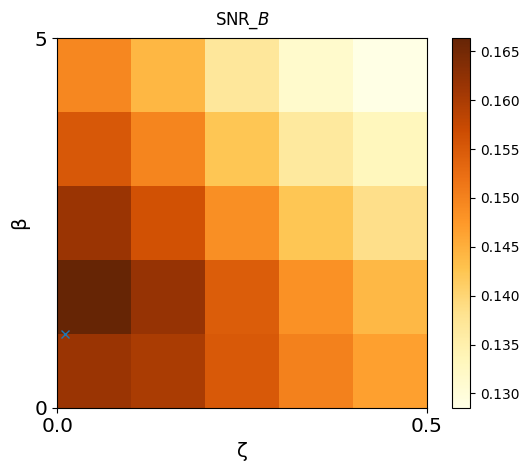

[[0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]]
[[0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [2. 2. 2. 2. 2.]
 [3. 3. 3. 3. 3.]
 [4. 4. 4. 4. 4.]]
1.0 1.0 0.0 0.01 10.0 1.0 4.0 1.0
Current iteration: zeta = 0.01, beta = 0.0
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.425e-07
  iter   40000, max |dF| = 7.405e-07
SNR:  0.15593803106917825
1.0 1.0 0.0 0.026591479484724942 10.0 1.0 4.0 1.0
Current iteration: zeta = 0.026591479484724942, beta = 0.0
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.425e-07
  iter   40000, max |dF| = 7.405e-07
SNR:  0.15525105948494633
1.0 1.0 0.

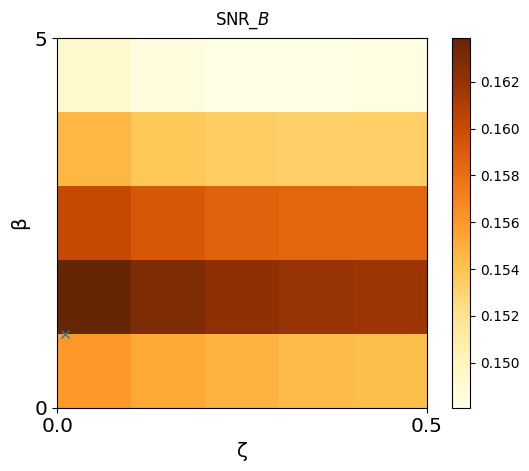

In [ ]:
kappa_vals = np.logspace(-3, 1, 5)

for val in kappa_vals:
  params = Params(
      gamma = 1.0,
      alpha = 1.0,
      beta  = 1.0,
      zeta  = 1.0,
      kappa = val,
      K = 1.0,
      rho0  = 4.0,
  )
  grid = Grid(r_max=15.0, N_r=140, N_theta=80)

  solver = PheromoneEnzymeSolver(params, grid)
  # print("Solving...")
  # solver.solve(max_iter=50000, tol=5e-8, print_every=10000)
  # print(f"\n  SNR = {solver.snr():.4f}")
  ax = plt.gca()
  img = solver.plot_metric_heatmap(name="SNR_$B$", fnc=PheromoneEnzymeSolver.bound_snr, param1="zeta", param2="beta", param1_max=0.5, num_cells_per_side=5, show_max=True, ax=ax)
  plt.gcf().colorbar(img, ax=ax)
  plt.show()

# print("\nPlotting...")
# solver.plot_2d(savepath='nondim_profiles_2d.png')
# solver.plot_axis(savepath='nondim_profiles_axis.png')
# solver.plot_surface(savepath='nondim_profiles_surface.png')
# print("Done.")

[[0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]]
[[0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [2. 2. 2. 2. 2.]
 [3. 3. 3. 3. 3.]
 [4. 4. 4. 4. 4.]]
1.0 1.0 0.0 0.01 0.5 1.0 4.0 1.0
Current iteration: zeta = 0.01, beta = 0.0
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.425e-07
  iter   40000, max |dF| = 7.405e-07
SNR:  0.1638357098934067
1.0 1.0 0.0 0.026591479484724942 0.5 1.0 4.0 1.0
Current iteration: zeta = 0.026591479484724942, beta = 0.0
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 3.008e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.425e-07
  iter   40000, max |dF| = 7.405e-07
SNR:  0.16564417883509525
1.0 1.0 0.0 0

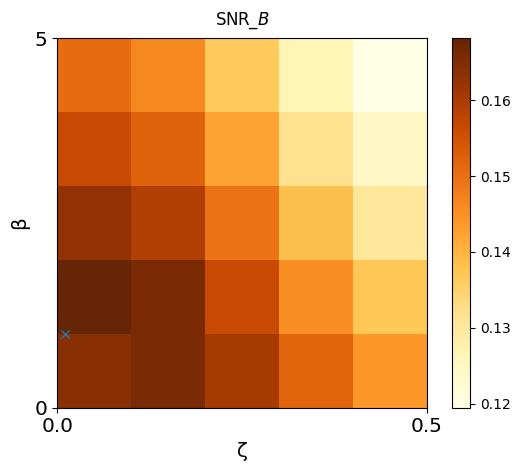

In [ ]:
params = Params(
    gamma = 1.0,
    alpha = 1.0,
    beta  = 1.0,
    zeta  = 1.0,
    kappa = 0.5,
    K = 1.0,
    rho0  = 4.0,
)
grid = Grid(r_max=15.0, N_r=140, N_theta=80)

solver = PheromoneEnzymeSolver(params, grid)
# print("Solving...")
# solver.solve(max_iter=50000, tol=5e-8, print_every=10000)
# print(f"\n  SNR = {solver.snr():.4f}")
ax = plt.gca()
img = solver.plot_metric_heatmap(name="SNR_$B$", fnc=PheromoneEnzymeSolver.bound_snr, param1="zeta", param2="beta", param1_max=0.5, num_cells_per_side=5, show_max=True, ax=ax)
plt.gcf().colorbar(img, ax=ax)
plt.show()

[[0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]]
[[ 0.  0.  0.  0.  0.]
 [ 4.  4.  4.  4.  4.]
 [ 8.  8.  8.  8.  8.]
 [12. 12. 12. 12. 12.]
 [16. 16. 16. 16. 16.]]
1.0 1.0 0.0 0.01 1.0 0.001 4.0 1.0
Current iteration: zeta = 0.01, beta = 0.0
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.425e-07
  iter   40000, max |dF| = 7.405e-07
SNR:  0.002294873050740356
1.0 1.0 0.0 0.026591479484724942 1.0 0.001 4.0 1.0
Current iteration: zeta = 0.026591479484724942, beta = 0.0
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.425e-07
  iter   40000, max |dF| = 7.405e-07
SNR:  0.

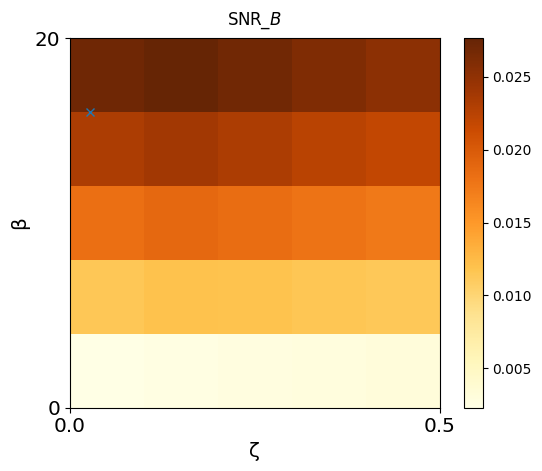

In [ ]:
params = Params(
    gamma = 1.0,
    alpha = 1.0,
    beta  = 1.0,
    zeta  = 1.0,
    kappa = 1.0,
    K = 0.001,
    rho0  = 4.0,
)
grid = Grid(r_max=15.0, N_r=140, N_theta=80)

solver = PheromoneEnzymeSolver(params, grid)
# print("Solving...")
# solver.solve(max_iter=50000, tol=5e-8, print_every=10000)
# print(f"\n  SNR = {solver.snr():.4f}")
ax = plt.gca()
img = solver.plot_metric_heatmap(name="SNR_$B$", fnc=PheromoneEnzymeSolver.bound_snr, param1="zeta", param2="beta", param1_max=0.5, param2_max=20, num_cells_per_side=5, show_max=True, ax=ax)
plt.gcf().colorbar(img, ax=ax)
plt.show()

[[0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]
 [0.01       0.02659148 0.07071068 0.18803015 0.5       ]]
[[  0.   0.   0.   0.   0.]
 [200. 200. 200. 200. 200.]
 [400. 400. 400. 400. 400.]
 [600. 600. 600. 600. 600.]
 [800. 800. 800. 800. 800.]]
1.0 1.0 0.0 0.01 1.0 0.001 4.0 1.0
Current iteration: zeta = 0.01, beta = 0.0
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.425e-07
  iter   40000, max |dF| = 7.405e-07
SNR:  0.002294873050740356
1.0 1.0 0.0 0.026591479484724942 1.0 0.001 4.0 1.0
Current iteration: zeta = 0.026591479484724942, beta = 0.0
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.425e-07
  iter   40000, max 

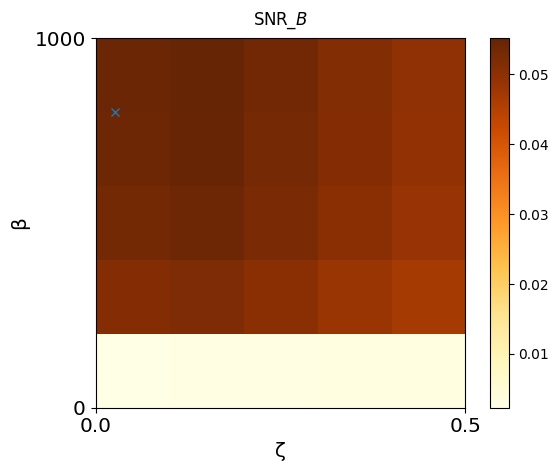

In [ ]:
params = Params(
    gamma = 1.0,
    alpha = 1.0,
    beta  = 1.0,
    zeta  = 1.0,
    kappa = 1.0,
    K = 0.001,
    rho0  = 4.0,
)
grid = Grid(r_max=15.0, N_r=140, N_theta=80)

solver = PheromoneEnzymeSolver(params, grid)
# print("Solving...")
# solver.solve(max_iter=50000, tol=5e-8, print_every=10000)
# print(f"\n  SNR = {solver.snr():.4f}")
ax = plt.gca()
img = solver.plot_metric_heatmap(name="SNR_$B$", fnc=PheromoneEnzymeSolver.bound_snr, param1="zeta", param2="beta", param1_max=0.5, param2_max=1000, num_cells_per_side=5, show_max=True, ax=ax)
plt.gcf().colorbar(img, ax=ax)
plt.show()

[[0.01       0.01495349 0.02236068 0.03343702 0.05      ]
 [0.01       0.01495349 0.02236068 0.03343702 0.05      ]
 [0.01       0.01495349 0.02236068 0.03343702 0.05      ]
 [0.01       0.01495349 0.02236068 0.03343702 0.05      ]
 [0.01       0.01495349 0.02236068 0.03343702 0.05      ]]
[[0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [2. 2. 2. 2. 2.]
 [3. 3. 3. 3. 3.]
 [4. 4. 4. 4. 4.]]
1.0 1.0 0.0 0.01 100.0 1.0 4.0 1.0
Current iteration: zeta = 0.01, beta = 0.0
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.425e-07
  iter   40000, max |dF| = 7.405e-07
SNR:  0.21959608783665813
1.0 1.0 0.0 0.014953487812212205 100.0 1.0 4.0 1.0
Current iteration: zeta = 0.014953487812212205, beta = 0.0
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.425e-07
  iter   40000, max |dF| = 7.405e-07
SNR:  0.219553409617555
1.0 1.0 0.

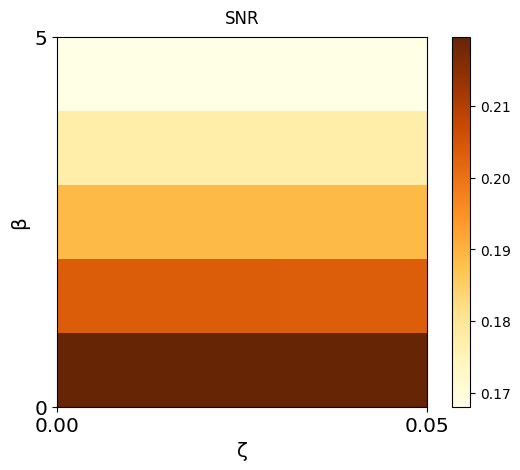

In [ ]:
params = Params(
    gamma = 1.0,
    alpha = 1.0,
    beta  = 1.0,
    zeta  = 1.0,
    kappa = 100.0,
    rho0  = 4.0,
)
grid = Grid(r_max=15.0, N_r=140, N_theta=80)

solver = PheromoneEnzymeSolver(params, grid)
# print("Solving...")
# solver.solve(max_iter=200000, tol=5e-8, print_every=10000)
# print(f"\n  SNR = {solver.snr():.4f}")
ax = plt.gca()
img = solver.plot_metric_heatmap(param1="zeta", param2="beta", param1_max=0.05, num_cells_per_side=5, ax=ax)
plt.gcf().colorbar(img, ax=ax)

# print("\nPlotting...")
# solver.plot_2d(savepath='nondim_profiles_2d.png')
# solver.plot_axis(savepath='nondim_profiles_axis.png')
# solver.plot_surface(savepath='nondim_profiles_surface.png')
# print("Done.")

[[1.00000000e-02 2.78255940e-02 7.74263683e-02 2.15443469e-01
  5.99484250e-01 1.66810054e+00 4.64158883e+00 1.29154967e+01
  3.59381366e+01 1.00000000e+02]
 [1.00000000e-02 2.78255940e-02 7.74263683e-02 2.15443469e-01
  5.99484250e-01 1.66810054e+00 4.64158883e+00 1.29154967e+01
  3.59381366e+01 1.00000000e+02]
 [1.00000000e-02 2.78255940e-02 7.74263683e-02 2.15443469e-01
  5.99484250e-01 1.66810054e+00 4.64158883e+00 1.29154967e+01
  3.59381366e+01 1.00000000e+02]
 [1.00000000e-02 2.78255940e-02 7.74263683e-02 2.15443469e-01
  5.99484250e-01 1.66810054e+00 4.64158883e+00 1.29154967e+01
  3.59381366e+01 1.00000000e+02]
 [1.00000000e-02 2.78255940e-02 7.74263683e-02 2.15443469e-01
  5.99484250e-01 1.66810054e+00 4.64158883e+00 1.29154967e+01
  3.59381366e+01 1.00000000e+02]
 [1.00000000e-02 2.78255940e-02 7.74263683e-02 2.15443469e-01
  5.99484250e-01 1.66810054e+00 4.64158883e+00 1.29154967e+01
  3.59381366e+01 1.00000000e+02]
 [1.00000000e-02 2.78255940e-02 7.74263683e-02 2.15443469e

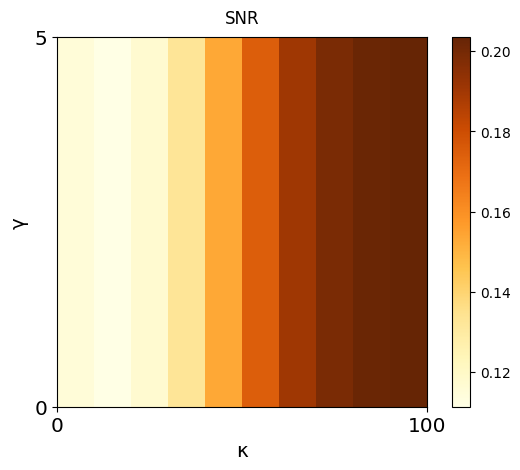

In [ ]:
params = Params(
    gamma = 1.0,
    alpha = 1.0,
    beta  = 1.0,
    zeta  = 1.0,
    kappa = 100.0,
    rho0  = 4.0,
)
grid = Grid(r_max=15.0, N_r=140, N_theta=80)

solver = PheromoneEnzymeSolver(params, grid)
# print("Solving...")
# solver.solve(max_iter=200000, tol=5e-8, print_every=10000)
# print(f"\n  SNR = {solver.snr():.4f}")
ax = plt.gca()
img = solver.plot_metric_heatmap(param1="kappa", param1_max=100, param2="gamma", num_cells_per_side=10, ax=ax)
plt.gcf().colorbar(img, ax=ax)

# print("\nPlotting...")
# solver.plot_2d(savepath='nondim_profiles_2d.png')
# solver.plot_axis(savepath='nondim_profiles_axis.png')
# solver.plot_surface(savepath='nondim_profiles_surface.png')
# print("Done.")

In [ ]:
K_vals = [0, 1.0, 100.0]

for val in K_vals:
  params = Params(
      gamma = 1.0,
      alpha = 1.0,
      beta  = 1.0,
      zeta  = 1.0,
      kappa = 1.0,
      K = val,
      rho0  = 4.0,
  )
  grid = Grid(r_max=15.0, N_r=140, N_theta=80)

  solver = PheromoneEnzymeSolver(params, grid)
  print("Solving...")
  solver.solve(max_iter=50000, tol=5e-8, print_every=10000)
  print(f"\n  Bound SNR = {solver.bound_snr():.4f}")
  # solver.plot_metric_heatmap(num_cells_per_side=5, ax=plt.gca())

  # print("\nPlotting...")
  # solver.plot_2d(savepath='nondim_profiles_2d.png')
  # solver.plot_axis(savepath='nondim_profiles_axis.png')
  # solver.plot_surface(savepath='nondim_profiles_surface.png')
# print("Done.")

# Effects of small and large K check out, so the question is now why isn't it affecting the SNR?

Solving...
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.465e-07
  iter   40000, max |dF| = 7.532e-07

  Bound SNR = -0.0000
Solving...
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.465e-07
  iter   40000, max |dF| = 7.532e-07

  Bound SNR = 0.1421
Solving...
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.465e-07
  iter   40000, max |dF| = 7.532e-07

  Bound SNR = 0.0164


In [ ]:
kappa_vals = [0, 1.0, 100.0]

for val in kappa_vals:
  params = Params(
      gamma = 1.0,
      alpha = 1.0,
      beta  = 1.0,
      zeta  = 1.0,
      kappa = val,
      K = 1.0,
      rho0  = 4.0,
  )
  grid = Grid(r_max=15.0, N_r=140, N_theta=80)

  solver = PheromoneEnzymeSolver(params, grid)
  print("Solving...")
  solver.solve(max_iter=50000, tol=5e-8, print_every=10000)
  print(f"\n  Bound SNR = {solver.bound_snr():.4f}")
  # solver.plot_metric_heatmap(num_cells_per_side=5, ax=plt.gca())

  # print("\nPlotting...")
  # solver.plot_2d(savepath='nondim_profiles_2d.png')
  # solver.plot_axis(savepath='nondim_profiles_axis.png')
  # solver.plot_surface(savepath='nondim_profiles_surface.png')
# print("Done.")

# Effects of small and large K check out, so the question is now why isn't it affecting the SNR?

Solving...
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.432e-07
  iter   40000, max |dF| = 7.417e-07

  Bound SNR = 0.1344
Solving...
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.465e-07
  iter   40000, max |dF| = 7.532e-07

  Bound SNR = 0.1421
Solving...
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.485e-07
  iter   40000, max |dF| = 7.598e-07

  Bound SNR = 0.1655


  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.434e-07
  iter   40000, max |dF| = 7.433e-07
4.050000000000001
6.050000000000001
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.485e-07
  iter   40000, max |dF| = 7.599e-07
4.050000000000001
6.050000000000001
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.343e-06
  iter   30000, max |dF| = 9.515e-07
  iter   40000, max |dF| = 7.690e-07
4.050000000000001
6.050000000000001


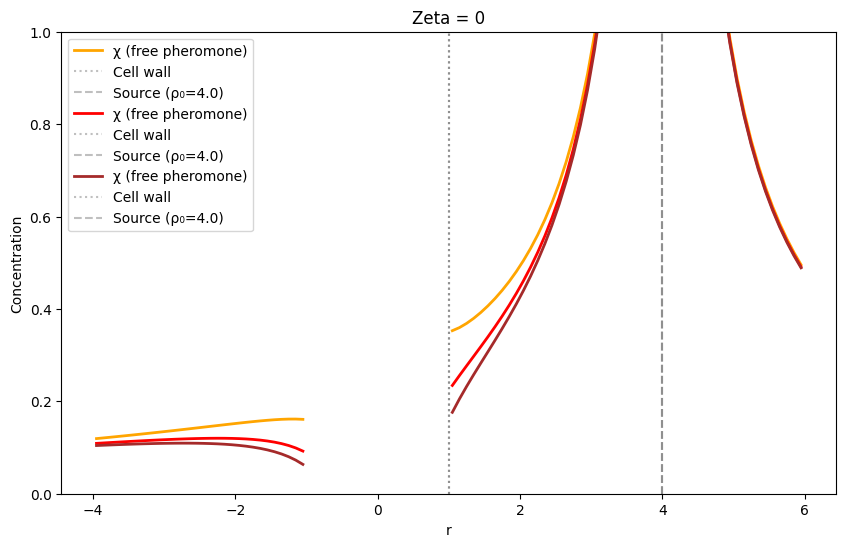

  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.432e-07
  iter   40000, max |dF| = 7.426e-07
4.050000000000001
6.050000000000001
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.474e-07
  iter   40000, max |dF| = 7.556e-07
4.050000000000001
6.050000000000001
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.343e-06
  iter   30000, max |dF| = 9.500e-07
  iter   40000, max |dF| = 7.630e-07
4.050000000000001
6.050000000000001


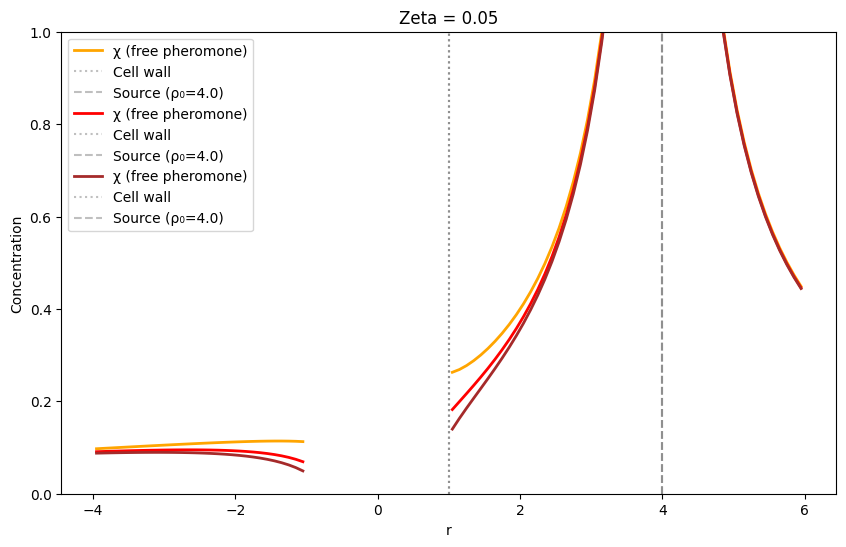

  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.431e-07
  iter   40000, max |dF| = 7.422e-07
4.050000000000001
6.050000000000001
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.466e-07
  iter   40000, max |dF| = 7.535e-07
4.050000000000001
6.050000000000001
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.488e-07
  iter   40000, max |dF| = 7.604e-07
4.050000000000001
6.050000000000001


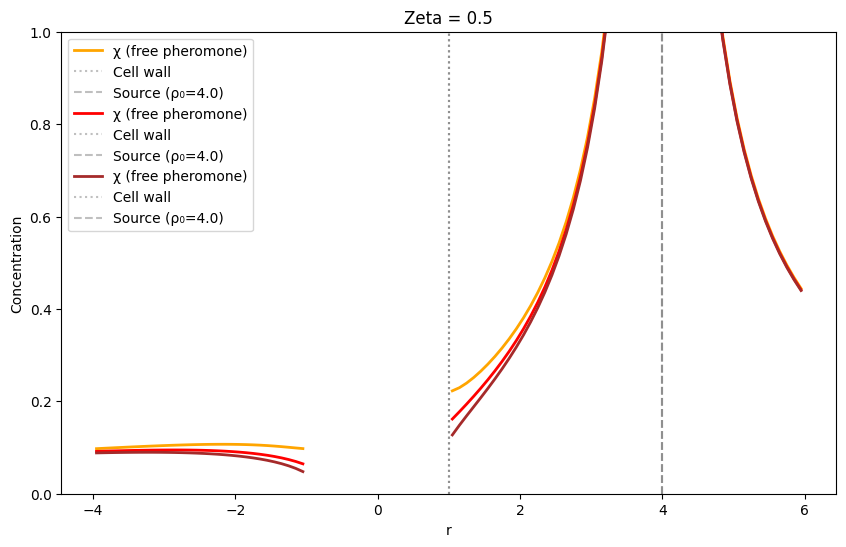

In [ ]:
zeta_vals = [0, 0.2, 2]

beta_settings = {
    0.1: "orange",
    1: "red",
    2: "brown"
}

for zeta_val in zeta_vals:
  ax = plt.gca()
  for beta_val in beta_settings.keys():
    params = Params(
        gamma = 1.0,
        alpha = 1.0,
        beta  = beta_val,
        zeta  = zeta_val,
        kappa = 1.0,
        rho0  = 4.0,
    )
    grid = Grid(r_max=15.0, N_r=140, N_theta=80)

    solver = PheromoneEnzymeSolver(params, grid)
    solver.solve(max_iter=50000, tol=5e-8, print_every=10000)

    solver.plot_axis(ax, color=beta_settings[beta_val])

  ax.set_ylim([0., 1.])
  ax.set_title(f"Zeta = {zeta_val}")
  plt.show()

  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.426e-07
  iter   40000, max |dF| = 7.406e-07
4.050000000000001
6.050000000000001
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.432e-07
  iter   40000, max |dF| = 7.417e-07
4.050000000000001
6.050000000000001
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.437e-07
  iter   40000, max |dF| = 7.424e-07
4.050000000000001
6.050000000000001


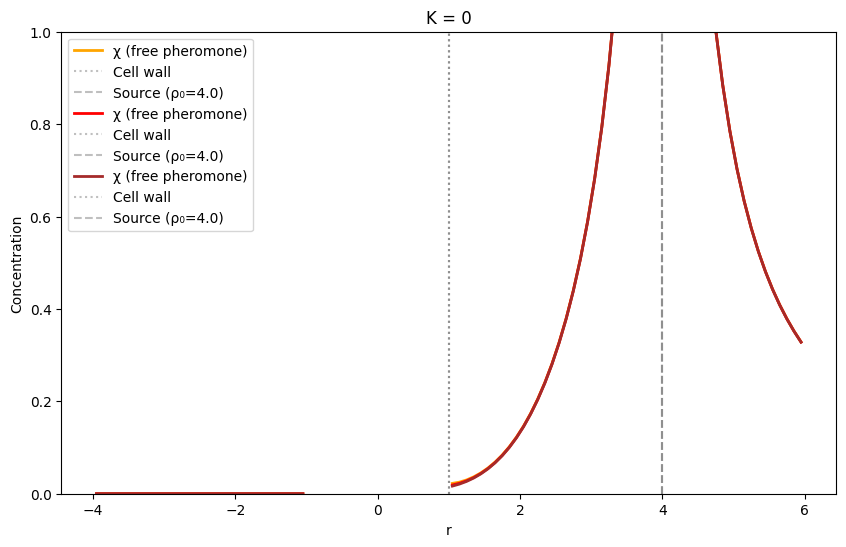

  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.431e-07
  iter   40000, max |dF| = 7.422e-07
4.050000000000001
6.050000000000001
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.465e-07
  iter   40000, max |dF| = 7.532e-07
4.050000000000001
6.050000000000001
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.487e-07
  iter   40000, max |dF| = 7.602e-07
4.050000000000001
6.050000000000001


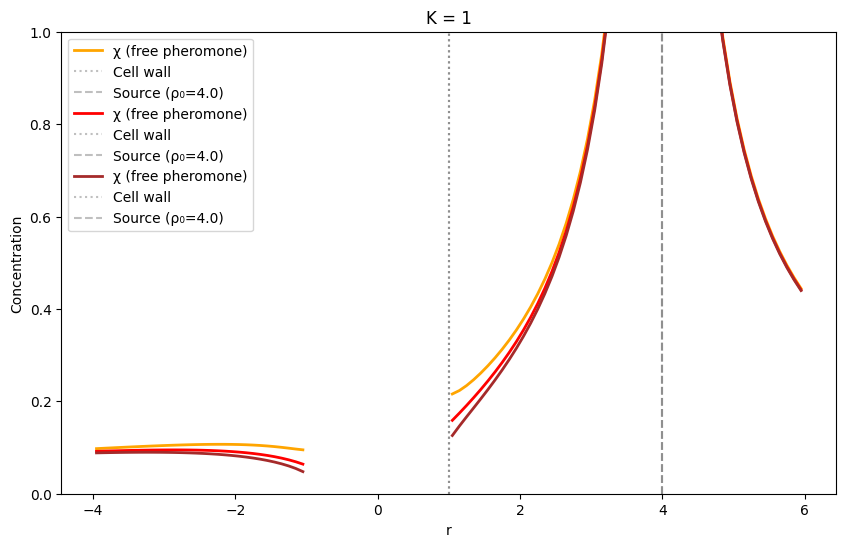

  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.434e-07
  iter   40000, max |dF| = 7.433e-07
4.050000000000001
6.050000000000001
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.342e-06
  iter   30000, max |dF| = 9.485e-07
  iter   40000, max |dF| = 7.598e-07
4.050000000000001
6.050000000000001
  iter       0, max |dF| = 1.701e-01
  iter   10000, max |dF| = 2.526e-06
  iter   20000, max |dF| = 1.343e-06
  iter   30000, max |dF| = 9.515e-07
  iter   40000, max |dF| = 7.689e-07
4.050000000000001
6.050000000000001


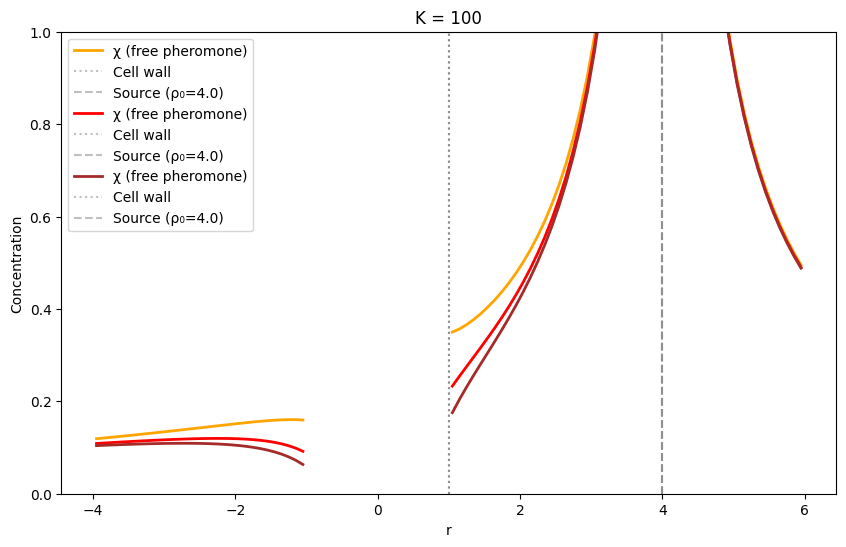

In [ ]:
kappa_vals = [0, 1, 100]

beta_settings = {
    0.1: "orange",
    1: "red",
    2: "brown"
}

for kappa_val in kappa_vals:
  ax = plt.gca()
  for beta_val in beta_settings.keys():
    params = Params(
        gamma = 1.0,
        alpha = 1.0,
        beta  = beta_val,
        zeta  = 1.0,
        kappa = kappa_val,
        rho0  = 4.0,
    )
    grid = Grid(r_max=15.0, N_r=140, N_theta=80)

    solver = PheromoneEnzymeSolver(params, grid)
    solver.solve(max_iter=50000, tol=5e-8, print_every=10000)

    solver.plot_axis(ax, color=beta_settings[beta_val])

  ax.set_ylim([0., 1.])
  ax.set_title(f"K = {kappa_val}")
  plt.show()